In [9]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from src.data.dataset_loader import WasteDatasetLoader
from src.data.preprocessing import DataPreprocessor
import cv2

Loading TrashNet dataset...


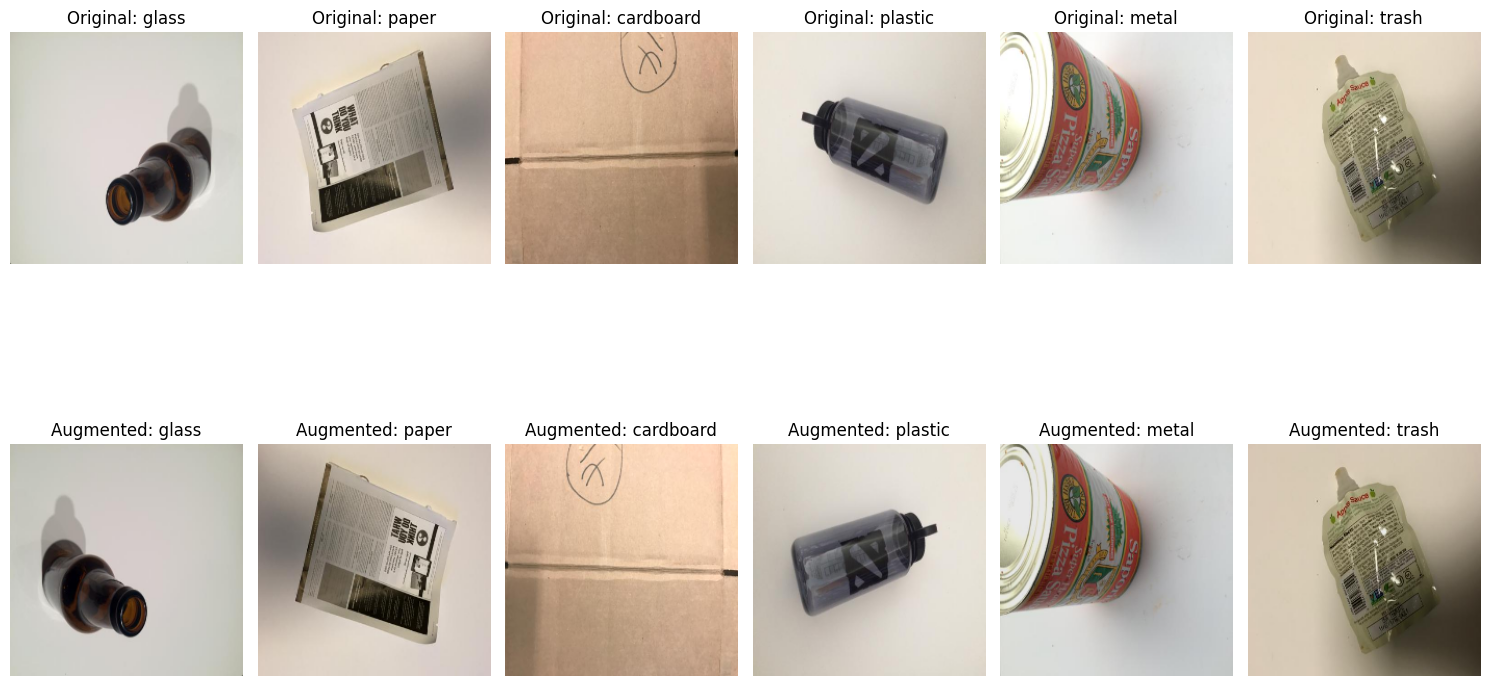

In [12]:
def test_preprocessing():
    """Test the preprocessing pipeline with proper visualization"""
    
    # Load data
    loader = WasteDatasetLoader()
    images, labels = loader.load_trashnet()
    
    # Initialize preprocessor
    preprocessor = DataPreprocessor()
    
    # Select one image from each category
    categories = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']
    selected_images = []
    selected_labels = []
    
    for class_idx in range(len(categories)):
        indices = np.where(labels == class_idx)[0]
        if len(indices) > 0:
            # Make a copy to avoid modifying the original data
            selected_images.append(images[indices[0]].copy())
            selected_labels.append(labels[indices[0]])
    
    # Convert to numpy arrays
    selected_images = np.array(selected_images)
    selected_labels = np.array(selected_labels)
    
    # Convert BGR to RGB for TensorFlow operations
    rgb_images = np.array([cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in selected_images])
    
    # Create custom augmentations manually instead of using DataPreprocessor
    augmented_images = []
    for img in rgb_images:
        # Convert to tensor
        img_tensor = tf.convert_to_tensor(img, dtype=tf.float32) / 255.0
        img_tensor = tf.expand_dims(img_tensor, 0)  # Add batch dimension
        
        # Apply augmentations one by one
        aug_tensor = tf.image.random_flip_left_right(img_tensor)
        aug_tensor = tf.image.random_brightness(aug_tensor, 0.1)
        aug_tensor = tf.clip_by_value(aug_tensor, 0.0, 1.0)  # Ensure values are in range
        
        # Convert back to numpy and scale to 0-255
        aug_img = tf.squeeze(aug_tensor).numpy() * 255
        aug_img = aug_img.astype(np.uint8)
        augmented_images.append(aug_img)
    
    # Visualize original vs augmented images
    plt.figure(figsize=(15, 10))
    
    for i in range(len(selected_images)):
        # Original image 
        plt.subplot(2, 6, i+1)
        rgb_img = cv2.cvtColor(selected_images[i], cv2.COLOR_BGR2RGB)
        plt.imshow(rgb_img)
        plt.title(f'Original: {categories[selected_labels[i]]}')
        plt.axis('off')
        
        # Augmented image
        plt.subplot(2, 6, i+7)
        plt.imshow(augmented_images[i])
        plt.title(f'Augmented: {categories[selected_labels[i]]}')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

test_preprocessing()